In [2]:
from tensorflow.keras import layers
from tensorflow import keras
from sklearn.model_selection import train_test_split
from ast import literal_eval
import tensorflow as tf
import pandas as pd
import numpy as np
import pickle
import torch
import os
import matplotlib.pyplot as plt

CSV_NAME = "arxiv_data_210930-054931.csv"
CANDIDATE_PATHS = [
    f"/content/{CSV_NAME}",
    f"/mnt/user-data/uploads/{CSV_NAME}",
    CSV_NAME,
    f"data/{CSV_NAME}",
]

csv_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        f"Could not find '{CSV_NAME}'. Please upload it and either place it "
        f"in the working directory or update CANDIDATE_PATHS above."
    )

arxiv_data = pd.read_csv(csv_path)
arxiv_data.head()

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...


In [3]:
arxiv_data.shape

(56181, 3)

In [4]:
arxiv_data.isnull().sum()

,0
terms,0
titles,0
abstracts,0


In [5]:
arxiv_data.duplicated().sum()

np.int64(15054)

In [6]:
labels_col = arxiv_data['terms'].apply(literal_eval)
labels = labels_col.explode().unique()
print("labels :",labels)
print("lenght :",len(labels))

labels : ['cs.LG' 'cs.AI' 'cs.CR' ... 'D.1.3; G.4; I.2.8; I.2.11; I.5.3; J.3'
 '68T07, 68T45, 68T10, 68T50, 68U35' 'I.2.0; G.3']
lenght : 1177


In [7]:
arxiv_data = arxiv_data[~arxiv_data['titles'].duplicated()]
print(f"There are {len(arxiv_data)} rows in the deduplicated dataset.")
print(sum(arxiv_data['terms'].value_counts()==1))
print(arxiv_data['terms'].nunique())

There are 41105 rows in the deduplicated dataset.
2503
3401


In [8]:
arxiv_data_filtered = arxiv_data.groupby('terms').filter(lambda x: len(x) > 1)
arxiv_data_filtered.shape

(38602, 3)

In [9]:
arxiv_data_filtered['terms'] = arxiv_data_filtered['terms'].apply(lambda x: literal_eval(x))
arxiv_data_filtered['terms'].values[:3]

array([list(['cs.LG']), list(['cs.LG', 'cs.AI']),
       list(['cs.LG', 'cs.CR', 'stat.ML'])], dtype=object)

In [10]:
train_df, test_df = train_test_split(
    arxiv_data_filtered,
    test_size=0.1,
    stratify=arxiv_data_filtered['terms'].apply(tuple).values,
)

val_df = test_df.sample(frac=0.5, random_state=42)
test_df = test_df.drop(val_df.index)

print(f"Number of rows in training set: {len(train_df)}")
print(f"Number of rows in validation set: {len(val_df)}")
print(f"Number of rows in test set: {len(test_df)}")

Number of rows in training set: 34741
Number of rows in validation set: 1930
Number of rows in test set: 1931


In [11]:
terms = tf.ragged.constant(train_df['terms'].values)
lookup = tf.keras.layers.StringLookup(output_mode='multi_hot')
lookup.adapt(terms)
vocab = lookup.get_vocabulary()

print("Vocabulary:\n")
print(vocab)

Vocabulary:

['[UNK]', np.str_('cs.CV'), np.str_('cs.LG'), np.str_('stat.ML'), np.str_('cs.AI'), np.str_('eess.IV'), np.str_('cs.RO'), np.str_('cs.CL'), np.str_('cs.NE'), np.str_('cs.GR'), np.str_('cs.CR'), np.str_('math.OC'), np.str_('eess.SP'), np.str_('cs.SI'), np.str_('cs.MM'), np.str_('cs.SY'), np.str_('cs.IR'), np.str_('eess.SY'), np.str_('cs.MA'), np.str_('cs.HC'), np.str_('math.IT'), np.str_('cs.IT'), np.str_('cs.DC'), np.str_('stat.AP'), np.str_('cs.CY'), np.str_('stat.ME'), np.str_('stat.TH'), np.str_('math.ST'), np.str_('eess.AS'), np.str_('cs.SD'), np.str_('cs.DS'), np.str_('q-bio.QM'), np.str_('q-bio.NC'), np.str_('cs.CG'), np.str_('stat.CO'), np.str_('cs.NI'), np.str_('cs.GT'), np.str_('math.NA'), np.str_('cs.SE'), np.str_('cs.NA'), np.str_('I.2.6'), np.str_('physics.chem-ph'), np.str_('cs.DB'), np.str_('physics.comp-ph'), np.str_('cond-mat.dis-nn'), np.str_('q-bio.BM'), np.str_('math.PR'), np.str_('cs.LO'), np.str_('cs.PL'), np.str_('68T45'), np.str_('cs.AR'), np.str_('p

In [12]:
sample_label = train_df["terms"].iloc[0]
label_binarized = lookup(sample_label)

print(f"Original label: {sample_label}")
print(f"Label-binarized representation: {label_binarized}")

Original label: ['cs.LG', 'cs.IR']
Label-binarized representation: [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
max_seqlen = 150
batch_size = 128
padding_token= "<pad>"
auto = tf.data.AUTOTUNE

def make_dataset(dataframe, is_train=True):
  labels = tf.ragged.constant(dataframe['terms'].values)
  label_binarized = lookup(labels).numpy()
  dataset = tf.data.Dataset.from_tensor_slices((dataframe['abstracts'].values, label_binarized))
  dataset = dataset.shuffle(batch_size * 10) if is_train else dataset

  return dataset.batch(batch_size)

In [14]:
train_dataset = make_dataset(train_df, is_train=True)
val_dataset = make_dataset(val_df, is_train=False)
test_dataset = make_dataset(test_df, is_train=False)

In [15]:
def invert_multi_hot(encoded_labels):
    hot_indices = np.argwhere(encoded_labels == 1.0)[..., 0]
    return np.take(vocab, hot_indices)

In [16]:
text_batch, label_batch = next(iter(train_dataset))
for i, text in enumerate(text_batch[:5]):
    label = label_batch[i].numpy()[None, ...]
    print(f"Abstract: {text}")
    print(f"Label(s): {invert_multi_hot(label[0])}")
    print(" ")

Abstract: b'Recently, deep convolutional neural networks (CNNs) have been demonstrated\nremarkable progress on single image super-resolution. However, as the depth and\nwidth of the networks increase, CNN-based super-resolution methods have been\nfaced with the challenges of computational complexity and memory consumption in\npractice. In order to solve the above questions, we propose a deep but compact\nconvolutional network to directly reconstruct the high resolution image from\nthe original low resolution image. In general, the proposed model consists of\nthree parts, which are feature extraction block, stacked information\ndistillation blocks and reconstruction block respectively. By combining an\nenhancement unit with a compression unit into a distillation block, the local\nlong and short-path features can be effectively extracted. Specifically, the\nproposed enhancement unit mixes together two different types of features and\nthe compression unit distills more useful information 

In [17]:
vocabulary = set()
train_df['abstracts'].str.lower().str.split().apply(vocabulary.update)
vocab_size = len(vocabulary)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 159189


In [18]:
text_vectorizer = layers.TextVectorization(max_tokens=vocab_size, ngrams=2, output_mode="tf_idf")
text_vectorizer.adapt(train_dataset.map(lambda text, label: text))

In [19]:
train_dataset = train_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)
validation_dataset = val_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)
test_dataset = test_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

model_1 = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(lookup.vocabulary_size(), activation="sigmoid")
])

model_1.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["binary_accuracy"]
)

early_stopping = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history_1 = model_1.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 52s 164ms/step - binary_accuracy: 0.9840 - loss: 0.0471 - val_binary_accuracy: 0.9947 - val_loss: 0.0182
Epoch 2/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 76s 154ms/step - binary_accuracy: 0.9950 - loss: 0.0172 - val_binary_accuracy: 0.9947 - val_loss: 0.0177
Epoch 3/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 42s 154ms/step - binary_accuracy: 0.9960 - loss: 0.0134 - val_binary_accuracy: 0.9947 - val_loss: 0.0185
Epoch 4/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 42s 152ms/step - binary_accuracy: 0.9967 - loss: 0.0110 - val_binary_accuracy: 0.9947 - val_loss: 0.0192
Epoch 5/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 42s 152ms/step - binary_accuracy: 0.9972 - loss: 0.0094 - val_binary_accuracy: 0.9946 - val_loss: 0.0193
Epoch 6/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - binary_accuracy: 0.9976 - loss: 0.0082 - val_binary_accuracy: 0.9945 - val_loss: 0.0206
Epoch 7/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 41s 152ms/step - binary_accuracy: 0.9978 - loss: 0.0075 - val_binary_accuracy: 0.9946 - va

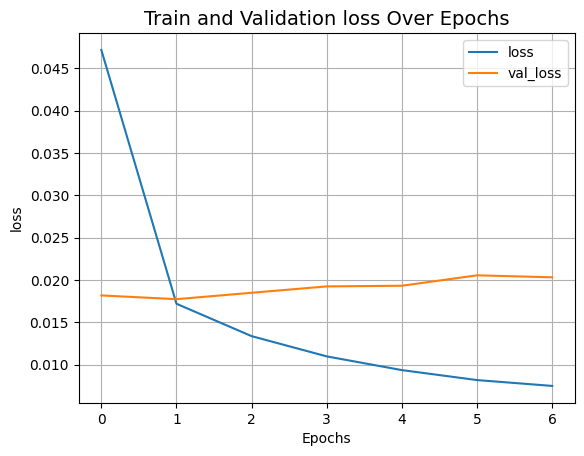

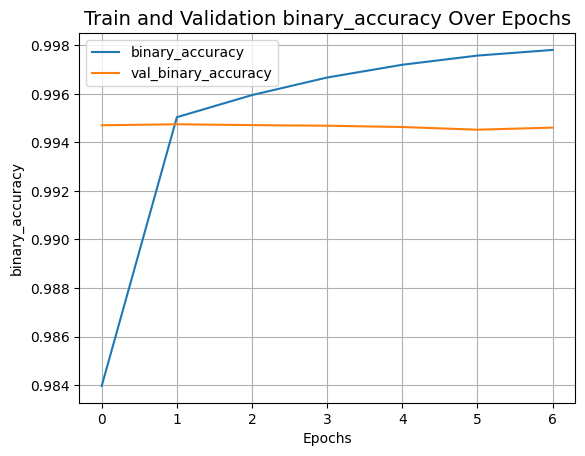

In [21]:
def plot_result(item):
    plt.plot(history_1.history[item], label=item)
    plt.plot(history_1.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_result("loss")
plot_result("binary_accuracy")

In [22]:
oss1, binary_acc1 = model_1.evaluate(test_dataset)
print(f"Binary accuracy of model_1 on the test set: {binary_acc1}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - binary_accuracy: 0.9946 - loss: 0.0178
Binary accuracy of model_1 on the test set: 0.9946109652519226


In [23]:
os.makedirs("models", exist_ok=True)

model_1.save("models/model.h5")

saved_text_vectorizer_config = text_vectorizer.get_config()
with open("models/text_vectorizer_config.pkl", "wb") as f:
    pickle.dump(saved_text_vectorizer_config, f)

with open("models/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

with open("models/text_vectorizer_weights.pkl", "wb") as f:
    pickle.dump(text_vectorizer.get_weights(), f)

In [24]:
from tensorflow.keras.layers import TextVectorization
import pickle
import keras
import numpy as np

loaded_model = keras.models.load_model("models/model.h5")

with open("models/text_vectorizer_config.pkl", "rb") as f:
    saved_text_vectorizer_config = pickle.load(f)

with open("models/text_vectorizer_weights.pkl", "rb") as f:
    weights = pickle.load(f)

with open("models/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

loaded_text_vectorizer = TextVectorization.from_config(saved_text_vectorizer_config)
if isinstance(weights, list) and len(weights) > 0:
    loaded_text_vectorizer.set_vocabulary(vocab, idf_weights=weights[0])
else:
    print("Warning: Saved weights are empty. Using the original 'text_vectorizer' from memory if available.")
    try:
        loaded_text_vectorizer = text_vectorizer
    except NameError:
        print("Error: Original vectorizer not found. Please re-run the 'adapt' and 'save' cells.")

In [25]:
def predict_category(abstract, model, vectorizer, label_lookup):
    preprocessed_abstract = vectorizer([abstract])
    predictions = model.predict(preprocessed_abstract)
    predicted_labels = label_lookup(np.round(predictions).astype(int)[0])

    return predicted_labels

In [26]:
new_abstract = "Graph neural networks (GNNs) have been widely used to learn vector\nrepresentation of graph-structured data and achieved better task performance\nthan conventional methods. The foundation of GNNs is the message passing\nprocedure, which propagates the information in a node to its neighbors. Since\nthis procedure proceeds one step per layer, the range of the information\npropagation among nodes is small in the lower layers, and it expands toward the\nhigher layers. Therefore, a GNN model has to be deep enough to capture global\nstructural information in a graph. On the other hand, it is known that deep GNN\nmodels suffer from performance degradation because they lose nodes' local\ninformation, which would be essential for good model performance, through many\nmessage passing steps. In this study, we propose multi-level attention pooling\n(MLAP) for graph-level classification tasks, which can adapt to both local and\nglobal structural information in a graph. It has an attention pooling layer for\neach message passing step and computes the final graph representation by\nunifying the layer-wise graph representations. The MLAP architecture allows\nmodels to utilize the structural information of graphs with multiple levels of\nlocalities because it preserves layer-wise information before losing them due\nto oversmoothing. Results of our experiments show that the MLAP architecture\nimproves the graph classification performance compared to the baseline\narchitectures. In addition, analyses on the layer-wise graph representations\nsuggest that aggregating information from multiple levels of localities indeed\nhas the potential to improve the discriminability of learned graph\nrepresentations."

predicted_categories = predict_category(new_abstract, loaded_model, loaded_text_vectorizer, invert_multi_hot)
print("Predicted Categories:", predicted_categories)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
Predicted Categories: ['cs.LG']


In [27]:
new_abstract = 'Deep networks and decision forests (such as random forests and gradient\nboosted trees) are the leading machine learning methods for structured and\ntabular data, respectively. Many papers have empirically compared large numbers\nof classifiers on one or two different domains (e.g., on 100 different tabular\ndata settings). However, a careful conceptual and empirical comparison of these\ntwo strategies using the most contemporary best practices has yet to be\nperformed. Conceptually, we illustrate that both can be profitably viewed as\n"partition and vote" schemes. Specifically, the representation space that they\nboth learn is a partitioning of feature space into a union of convex polytopes.\nFor inference, each decides on the basis of votes from the activated nodes.\nThis formulation allows for a unified basic understanding of the relationship\nbetween these methods. Empirically, we compare these two strategies on hundreds\nof tabular data settings, as well as several vision and auditory settings. Our\nfocus is on datasets with at most 10,000 samples, which represent a large\nfraction of scientific and biomedical datasets. In general, we found forests to\nexcel at tabular and structured data (vision and audition) with small sample\nsizes, whereas deep nets performed better on structured data with larger sample\nsizes. This suggests that further gains in both scenarios may be realized via\nfurther combining aspects of forests and networks. We will continue revising\nthis technical report in the coming months with updated results.'

predicted_categories = predict_category(new_abstract, loaded_model, loaded_text_vectorizer, invert_multi_hot)
print("Predicted Categories:", predicted_categories)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Categories: ['cs.LG' 'cs.AI']


In [28]:
arxiv_data.drop(columns = ["terms", "abstracts"], inplace = True)
arxiv_data.drop_duplicates(inplace = True)
arxiv_data.reset_index(drop = True, inplace = True)
pd.set_option('display.max_colwidth', None)
arxiv_data

,titles
0,Multi-Level Attention Pooling for Graph Neural Networks: Unifying Graph Representations with Multiple Localities
1,Decision Forests vs. Deep Networks: Conceptual Similarities and Empirical Differences at Small Sample Sizes
2,Power up! Robust Graph Convolutional Network via Graph Powering
3,Releasing Graph Neural Networks with Differential Privacy Guarantees
4,Recurrence-Aware Long-Term Cognitive Network for Explainable Pattern Classification
...,...
41100,An experimental study of graph-based semi-supervised classification with additional node information
41101,Bayesian Differential Privacy through Posterior Sampling
41102,Mining Spatio-temporal Data on Industrialization from Historical Registries
41103,Wav2Letter: an End-to-End ConvNet-based Speech Recognition System


In [29]:
from sentence_transformers import SentenceTransformer, util
import os

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

if 'titles' in arxiv_data.columns:
    sentences = arxiv_data['titles'].tolist()
    embeddings = model.encode(sentences, show_progress_bar=True)
else:
    print("Error: 'titles' column not found in arxiv_data. Please re-run the data loading cells.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1285 [00:00<?, ?it/s]

In [30]:
c = 0

for sentence, embedding in zip(sentences, embeddings):
    print("Sentence:", sentence)
    print("Embedding:", embedding)
    print("")

    if c >= 5:
      break
    c += 1

Sentence: Multi-Level Attention Pooling for Graph Neural Networks: Unifying Graph Representations with Multiple Localities
Embedding: [ 6.64340556e-02 -4.95459773e-02  6.38808683e-02 -2.82658394e-02
  6.94541633e-02  5.14024645e-02 -3.92372049e-02 -6.01334684e-02
 -5.88566577e-03 -4.16622497e-02  2.61420198e-02 -7.35904947e-02
 -1.88340098e-02  5.29376231e-02 -3.59027274e-02  7.48135149e-02
  6.94931597e-02 -2.33731139e-03 -1.75369978e-02 -1.01532543e-03
  6.97972178e-02 -5.65803349e-02  5.96184134e-02  4.10587564e-02
  8.57779607e-02  4.63837162e-02 -5.10073714e-02 -4.05410156e-02
  4.53708619e-02  6.67747157e-03  1.06340587e-01  6.82450607e-02
  2.95313727e-03  6.91113472e-02 -1.53357424e-02  7.92678446e-02
 -1.49697289e-01  2.57561617e-02  3.93775590e-02  5.25156707e-02
 -5.99678140e-04  4.33896035e-02  3.59695256e-02  8.13650787e-02
  8.18701908e-02  2.40489133e-02 -2.82293167e-02  9.89284888e-02
  1.97786354e-02 -4.69627455e-02 -8.14741291e-03 -5.35849892e-02
 -5.72295301e-02 -6.2

In [31]:
os.makedirs("models", exist_ok=True)

with open('models/embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings, f)
with open('models/sentences.pkl', 'wb') as f:
    pickle.dump(sentences, f)

with open('models/rec_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [32]:
embeddings = pickle.load(open('models/embeddings.pkl','rb'))
sentences = pickle.load(open('models/sentences.pkl','rb'))
rec_model = pickle.load(open('models/rec_model.pkl','rb'))

In [33]:
def recommendation(input_paper):
  cosine_scores = util.cos_sim(embeddings, rec_model.encode([input_paper]))
  top_similar_papers = torch.topk(cosine_scores, dim=0, k=min(5, len(sentences)), sorted=True)
  papers_list = []

  for i in top_similar_papers.indices:
    papers_list.append(sentences[i.item()])

  return papers_list

In [34]:
input_paper = input("Enter the title of any paper you like")
recommend_papers = recommendation(input_paper)


print("We recommend to read this paper............")
print("=============================================")
for paper in recommend_papers:
    print(paper)

We recommend to read this paper............
Techniques for Automated Machine Learning
Solving Machine Learning Problems
Machine learning with limited data
Towards a theory of machine learning
Transformative Machine Learning


In [35]:
input_paper = input("Enter the title of any paper you like")
recommend_papers = recommendation(input_paper)


print("We recommend to read this paper............")
print("=============================================")
for paper in recommend_papers:
    print(paper)

We recommend to read this paper............
Reinforcement Learning
Imitating Interactive Intelligence
Interpretable Artificial Intelligence through the Lens of Feature Interaction
Neural Algorithmic Reasoning
Better AI through Logical Scaffolding


In [36]:
input_paper = input("Enter the title of any paper you like")
recommend_papers = recommendation(input_paper)


print("We recommend to read this paper............")
print("=============================================")
for paper in recommend_papers:
    print(paper)

We recommend to read this paper............
GMM-Based Generative Adversarial Encoder Learning
Student's t-Generative Adversarial Networks
Diverse M-Best Solutions by Dynamic Programming
The iWildCam 2021 Competition Dataset
MemGEN: Memory is All You Need


In [37]:
import torch
import sentence_transformers
import tensorflow

print(f"Torch version: {torch.__version__}")
print(f"Sentence Transformers version: {sentence_transformers.__version__}")
print(f"TensorFlow version: {tensorflow.__version__}")

Torch version: 2.11.0+cu128
Sentence Transformers version: 5.6.0
TensorFlow version: 2.20.0
